In [74]:
import pandas as pd

In [73]:
#load dataset
df_cpi = pd.read_csv("retaildataset.csv")

In [75]:
print(df_cpi.head())
print(df_cpi.columns)

  STATISTIC       STATISTIC Label  TLIST(M1)         Month  C02071V02502  \
0     CPM02  Consumer Price Index     192201  1922 January             1   
1     CPM02  Consumer Price Index     192201  1922 January             2   
2     CPM02  Consumer Price Index     192201  1922 January             3   
3     CPM02  Consumer Price Index     192201  1922 January             4   
4     CPM02  Consumer Price Index     192201  1922 January             5   

  Selected Base Reference Period        UNIT  VALUE  
0             Base July 1914=100  Base = 100  191.0  
1           Base August 1947=100  Base = 100    NaN  
2           Base August 1953=100  Base = 100    NaN  
3         Base November 1968=100  Base = 100    NaN  
4         Base November 1975=100  Base = 100    NaN  
Index(['STATISTIC', 'STATISTIC Label', 'TLIST(M1)', 'Month', 'C02071V02502',
       'Selected Base Reference Period', 'UNIT', 'VALUE'],
      dtype='object')


In [76]:
#convert Month to real date & VALUE to numeric
df_cpi["Month"] = pd.to_datetime(df_cpi["Month"], errors="coerce")
df_cpi["VALUE"] = pd.to_numeric(df_cpi["VALUE"], errors="coerce")

/tmp/ipython-input-580562582.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_cpi["Month"] = pd.to_datetime(df_cpi["Month"], errors="coerce")


remove missing values

In [77]:
df_cpi = df_cpi.dropna(subset=["Month", "VALUE"])

In [78]:
mask_base = df_cpi["Selected Base Reference Period"] == "Base December 2023=100"
#only keep CPI rows that use the same base definition (Base December 2023 = 100)
df_cpi_base = df_cpi[mask_base].copy()

In [79]:
df_cpi_y = df_cpi_base[df_cpi_base["Month"] >= "2020-01-01"].copy()
#restrict datafrom 2020 onwards (COVID inflation)

In [80]:
df_cpi_y = df_cpi_y[["Month", "VALUE"]].rename(columns={"VALUE": "CPI_monthly"})
#rename VALUE to CPI_monthly

print(df_cpi_y.head())
print(df_cpi_y.shape)

           Month  CPI_monthly
15300 2020-01-01         84.0
15313 2020-02-01         84.5
15326 2020-03-01         84.8
15339 2020-04-01         84.5
15352 2020-05-01         84.0
(66, 2)


In [81]:
df_sector = pd.read_csv("sector.csv")#sector level dataset
print(df_sector.head())
print(df_sector.columns)

  STATISTIC                           Statistic Label  TLIST(A1)  Year  \
0  CPA01C06  Consumer Price Index (Base Dec 2023=100)       1975  1975   
1  CPA01C06  Consumer Price Index (Base Dec 2023=100)       1975  1975   
2  CPA01C06  Consumer Price Index (Base Dec 2023=100)       1975  1975   
3  CPA01C06  Consumer Price Index (Base Dec 2023=100)       1975  1975   
4  CPA01C06  Consumer Price Index (Base Dec 2023=100)       1975  1975   

  C01779V03424                                   Commodity Group  \
0            -                                         All items   
1           01                  Food and non-alcoholic beverages   
2           02                   Alcoholic beverages and tobacco   
3           03                             Clothing and footwear   
4           04  Housing, water, electricity, gas and other fuels   

                UNIT  VALUE  
0  Base Dec 2023=100   12.3  
1  Base Dec 2023=100    NaN  
2  Base Dec 2023=100    NaN  
3  Base Dec 2023=100    Na

In [82]:
#check both are numeric
df_sector["Year"] = pd.to_numeric(df_sector["Year"], errors="coerce")
df_sector["VALUE"] = pd.to_numeric(df_sector["VALUE"], errors="coerce")

In [83]:
df_sector = df_sector.dropna(subset=["Year"])#remove missing year

In [84]:
df_sector_recent = df_sector[df_sector["Year"] >= 2015].copy()#keep 2015 onwards

In [85]:
df_sector_recent = df_sector_recent.rename(columns={"Commodity Group": "Category","VALUE": "CPI_sector"})
#rename column

print(df_sector_recent.head())
print(df_sector_recent["Category"].unique()[:10])

    STATISTIC                           Statistic Label  TLIST(A1)  Year  \
520  CPA01C06  Consumer Price Index (Base Dec 2023=100)       2015  2015   
521  CPA01C06  Consumer Price Index (Base Dec 2023=100)       2015  2015   
522  CPA01C06  Consumer Price Index (Base Dec 2023=100)       2015  2015   
523  CPA01C06  Consumer Price Index (Base Dec 2023=100)       2015  2015   
524  CPA01C06  Consumer Price Index (Base Dec 2023=100)       2015  2015   

    C01779V03424                                          Category  \
520            -                                         All items   
521           01                  Food and non-alcoholic beverages   
522           02                   Alcoholic beverages and tobacco   
523           03                             Clothing and footwear   
524           04  Housing, water, electricity, gas and other fuels   

                  UNIT  CPI_sector  
520  Base Dec 2023=100        82.8  
521  Base Dec 2023=100        90.7  
522  Base D

In [86]:
#bulid data column for merging
df_sector_recent["Date"] = pd.to_datetime(df_sector_recent["Year"].astype(int).astype(str) + "-01-01")
#take only field needed
df_sector_final = df_sector_recent[["Date", "Year", "Category", "CPI_sector"]].copy()
print(df_sector_final.head())

          Date  Year                                          Category  \
520 2015-01-01  2015                                         All items   
521 2015-01-01  2015                  Food and non-alcoholic beverages   
522 2015-01-01  2015                   Alcoholic beverages and tobacco   
523 2015-01-01  2015                             Clothing and footwear   
524 2015-01-01  2015  Housing, water, electricity, gas and other fuels   

     CPI_sector  
520        82.8  
521        90.7  
522        77.7  
523       108.7  
524        61.3  


In [87]:
df_cpi_y["Year"] = df_cpi_y["Month"].dt.year #extract Year from monthly CPI to join with sector Year

In [88]:
df_cpi_with_sectors = pd.merge(df_cpi_y,df_sector_final[["Year", "Category", "CPI_sector"]],on="Year",how="left")
#keep every month from CPI and attach matching sector values by Year
print(df_cpi_with_sectors.head())
print(df_cpi_with_sectors.shape)

       Month  CPI_monthly  Year  \
0 2020-01-01         84.0  2020   
1 2020-01-01         84.0  2020   
2 2020-01-01         84.0  2020   
3 2020-01-01         84.0  2020   
4 2020-01-01         84.0  2020   

                                           Category  CPI_sector  
0                                         All items        84.0  
1                  Food and non-alcoholic beverages        84.1  
2                   Alcoholic beverages and tobacco        85.9  
3                             Clothing and footwear        94.9  
4  Housing, water, electricity, gas and other fuels        67.2  
(4686, 5)


In [89]:
print(df_cpi_with_sectors.head(10))

       Month  CPI_monthly  Year  \
0 2020-01-01         84.0  2020   
1 2020-01-01         84.0  2020   
2 2020-01-01         84.0  2020   
3 2020-01-01         84.0  2020   
4 2020-01-01         84.0  2020   
5 2020-01-01         84.0  2020   
6 2020-01-01         84.0  2020   
7 2020-01-01         84.0  2020   
8 2020-01-01         84.0  2020   
9 2020-01-01         84.0  2020   

                                            Category  CPI_sector  
0                                          All items        84.0  
1                   Food and non-alcoholic beverages        84.1  
2                    Alcoholic beverages and tobacco        85.9  
3                              Clothing and footwear        94.9  
4   Housing, water, electricity, gas and other fuels        67.2  
5  Furnishings, household equipment and routine h...        94.4  
6                                             Health        93.4  
7                                          Transport        81.4  
8          

In [90]:
print("Shape:", df_cpi_with_sectors.shape)

Shape: (4686, 5)


In [91]:
output_filename = "cpi_sectors_merged.csv"

df_cpi_with_sectors.to_csv(output_filename, index=False)
print("Saved file:", output_filename)

Saved file: cpi_sectors_merged.csv


In [92]:
from google.colab import files
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [93]:
cpi = pd.read_csv("cpi_sectors_merged.csv")#urban vs rural dataset

In [94]:
#extract year and month number from the monthly CPI date
cpi["Month"] = pd.to_datetime(cpi["Month"])
cpi["Year"] = cpi["Month"].dt.year
cpi["MonthNumber"] = cpi["Month"].dt.month

In [95]:
ur = pd.read_csv("urbanrural.csv")

In [96]:

ur["Year"] = ur["TLIST(M1)"].str.slice(0, 4).astype(int)
ur["MonthNumber"] = ur["TLIST(M1)"].str.slice(5, 7).astype(int)

In [97]:
ur_pivot = ur.pivot_table(index=["Year", "MonthNumber"],columns="Location",values="VALUE").reset_index()
#each row is Year+Month & so separate columns for State/Urban/Rural CPI

In [98]:
ur_pivot = ur_pivot.rename(columns={"State": "CPI_state_urb_rur","Urban areas": "CPI_urban","Rural areas": "CPI_rural"})

In [99]:
cpi_urban_rural = pd.merge(cpi,ur_pivot,on=["Year", "MonthNumber"],how="left")
#merge monthly CPI+sectors with urban/rural

In [100]:
cpi_urban_rural.to_csv("cpi_sectors_urbanrural_merged.csv", index=False)

In [101]:
from google.colab import files
files.download("cpi_sectors_urbanrural_merged.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
merged = pd.read_csv("cpi_sectors_urbanrural_merged.csv")
merged["Month"] = pd.to_datetime(merged["Month"], errors="coerce")

In [104]:
print(merged.info())
print(merged.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4686 entries, 0 to 4685
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Month              4686 non-null   datetime64[ns]
 1   CPI_monthly        4686 non-null   float64       
 2   Year               4686 non-null   int64         
 3   Category           4680 non-null   object        
 4   CPI_sector         4680 non-null   float64       
 5   MonthNumber        4686 non-null   int64         
 6   CPI_rural          3510 non-null   float64       
 7   CPI_state_urb_rur  3510 non-null   float64       
 8   CPI_urban          3510 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2), object(1)
memory usage: 329.6+ KB
None
       Month  CPI_monthly  Year  \
0 2020-01-01         84.0  2020   
1 2020-01-01         84.0  2020   
2 2020-01-01         84.0  2020   
3 2020-01-01         84.0  2020   
4 2020-01-01         84.0 

In [105]:

print(merged.columns)
print(merged[["Month","Year","Category","CPI_sector"]].head())

merged["CPI_sector"] = pd.to_numeric(merged["CPI_sector"], errors="coerce")
print(merged["CPI_sector"].isna().mean())#check missing


Index(['Month', 'CPI_monthly', 'Year', 'Category', 'CPI_sector', 'MonthNumber',
       'CPI_rural', 'CPI_state_urb_rur', 'CPI_urban'],
      dtype='object')
       Month  Year                                          Category  \
0 2020-01-01  2020                                         All items   
1 2020-01-01  2020                  Food and non-alcoholic beverages   
2 2020-01-01  2020                   Alcoholic beverages and tobacco   
3 2020-01-01  2020                             Clothing and footwear   
4 2020-01-01  2020  Housing, water, electricity, gas and other fuels   

   CPI_sector  
0        84.0  
1        84.1  
2        85.9  
3        94.9  
4        67.2  
0.0012804097311139564


In [106]:
recent = merged[merged["Year"] >= 2020].copy()
print(recent["Year"].min(), recent["Year"].max(), recent.shape)

#average CPI by sector in first and last year
start_year = recent["Year"].min()
end_year   = recent["Year"].max()

sector_start = (recent[recent["Year"] == start_year].groupby("Category")["CPI_sector"].mean())
sector_end = (recent[recent["Year"] == end_year].groupby("Category")["CPI_sector"].mean())

print(sector_start.head())
print(sector_end.head())


2020 2025 (4686, 9)
Category
Alcoholic beverages and tobacco    105.600000
All items                           87.150000
Clothing and footwear               60.000000
Communications                      71.933333
Education                          125.883333
Name: CPI_sector, dtype: float64
Series([], Name: CPI_sector, dtype: float64)


Sector impacts: food vs housing vs transport

In [107]:
#only use years where sector CPI is not missing
valid_years = (recent.dropna(subset=["CPI_sector"])["Year"].unique())
valid_years = sorted(valid_years)
print(valid_years)

start_year = valid_years[0]
end_year   = valid_years[-1]

#re‑compute start and end avg
sector_start = (recent[recent["Year"] == start_year].groupby("Category")["CPI_sector"].mean())
sector_end = (recent[recent["Year"] == end_year].groupby("Category")["CPI_sector"].mean())

#percentage change in each sector between start and end year
sector_change = ((sector_end - sector_start) / sector_start * 100).sort_values(ascending=False)
print(sector_change.head())


[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Category
Housing, water, electricity, gas and other fuels    48.020654
Transport                                           24.792736
Restaurants and hotels                              23.882634
Food and non-alcoholic beverages                    21.063035
All items                                           20.271562
Name: CPI_sector, dtype: float64


,% change 2020–2024
Category,
"Housing, water, electricity, gas and other fuels",48.020654
Transport,24.792736
Restaurants and hotels,23.882634
Food and non-alcoholic beverages,21.063035
All items,20.271562
Alcoholic beverages and tobacco,20.012626
Recreation and culture,17.339374
Health,7.627259
Communications,7.553290


<Figure size 800x500 with 0 Axes>

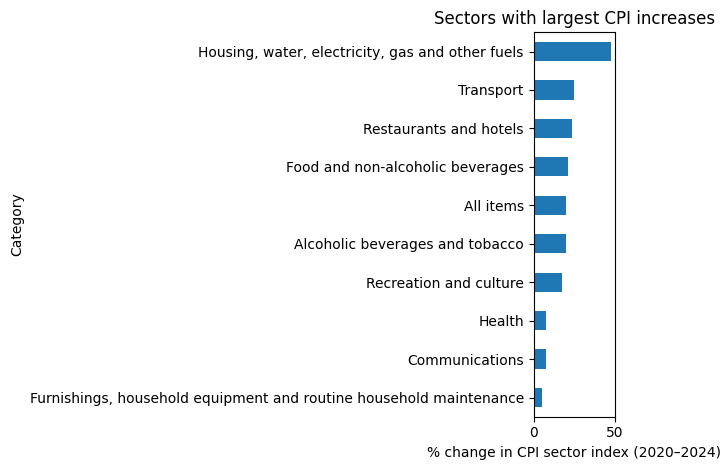

In [108]:
sector_change = ((sector_end - sector_start) / sector_start * 100).sort_values(ascending=False)

#put top 10 sector changes into a small table
sector_change_top = sector_change.head(10).to_frame(name="% change 2020–2024")
display(sector_change_top)

#bar chart of sectors with largest CPI inc
plt.figure(figsize=(8,5))
sector_change_top.sort_values("% change 2020–2024").plot(kind="barh", legend=False)
plt.xlabel("% change in CPI sector index (2020–2024)")
plt.title("Sectors with largest CPI increases")
plt.tight_layout()
plt.show()


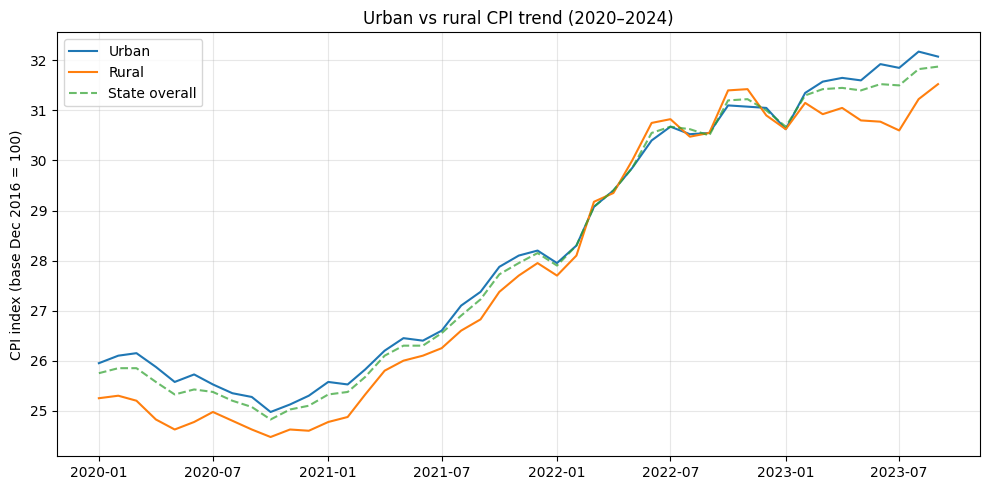

In [109]:
#urban vs rural CPI trends
#take one row per month
monthly_loc = (merged.sort_values("Month").drop_duplicates(subset=["Month"])[["Month", "CPI_urban", "CPI_rural", "CPI_state_urb_rur"]])
monthly_loc = monthly_loc[monthly_loc["Month"] >= "2020-01-01"]

plt.figure(figsize=(10,5))
plt.plot(monthly_loc["Month"], monthly_loc["CPI_urban"], label="Urban")
plt.plot(monthly_loc["Month"], monthly_loc["CPI_rural"], label="Rural")
plt.plot(monthly_loc["Month"], monthly_loc["CPI_state_urb_rur"],label="State overall", linestyle="--", alpha=0.7)

plt.ylabel("CPI index (base Dec 2016 = 100)")
plt.title("Urban vs rural CPI trend (2020–2024)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [110]:
#annual avg CPI for urban and rural,
monthly_loc["Year"] = monthly_loc["Month"].dt.year
avg_by_year = (monthly_loc.groupby("Year")[["CPI_urban","CPI_rural"]].mean())
avg_growth = avg_by_year.pct_change()*100  #year‑on‑year % change
display(avg_growth.tail())


/tmp/ipython-input-3490810009.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  avg_growth = avg_by_year.pct_change()*100  #year‑on‑year % change


,CPI_urban,CPI_rural
Year,,
2021,4.659119,5.871006
2022,12.055413,14.283451
2023,5.505394,3.026942
2024,0.000000,0.000000
2025,0.000000,0.000000


In [111]:

print("\nMissing values per column (%):")
print(merged.isna().mean() * 100)



Missing values per column (%):
Month                 0.000000
CPI_monthly           0.000000
Year                  0.000000
Category              0.128041
CPI_sector            0.128041
MonthNumber           0.000000
CPI_rural            25.096031
CPI_state_urb_rur    25.096031
CPI_urban            25.096031
dtype: float64


In [112]:
# DUPLICATES
print("\nNumber of duplicate rows:", merged.duplicated().sum())




Number of duplicate rows: 36


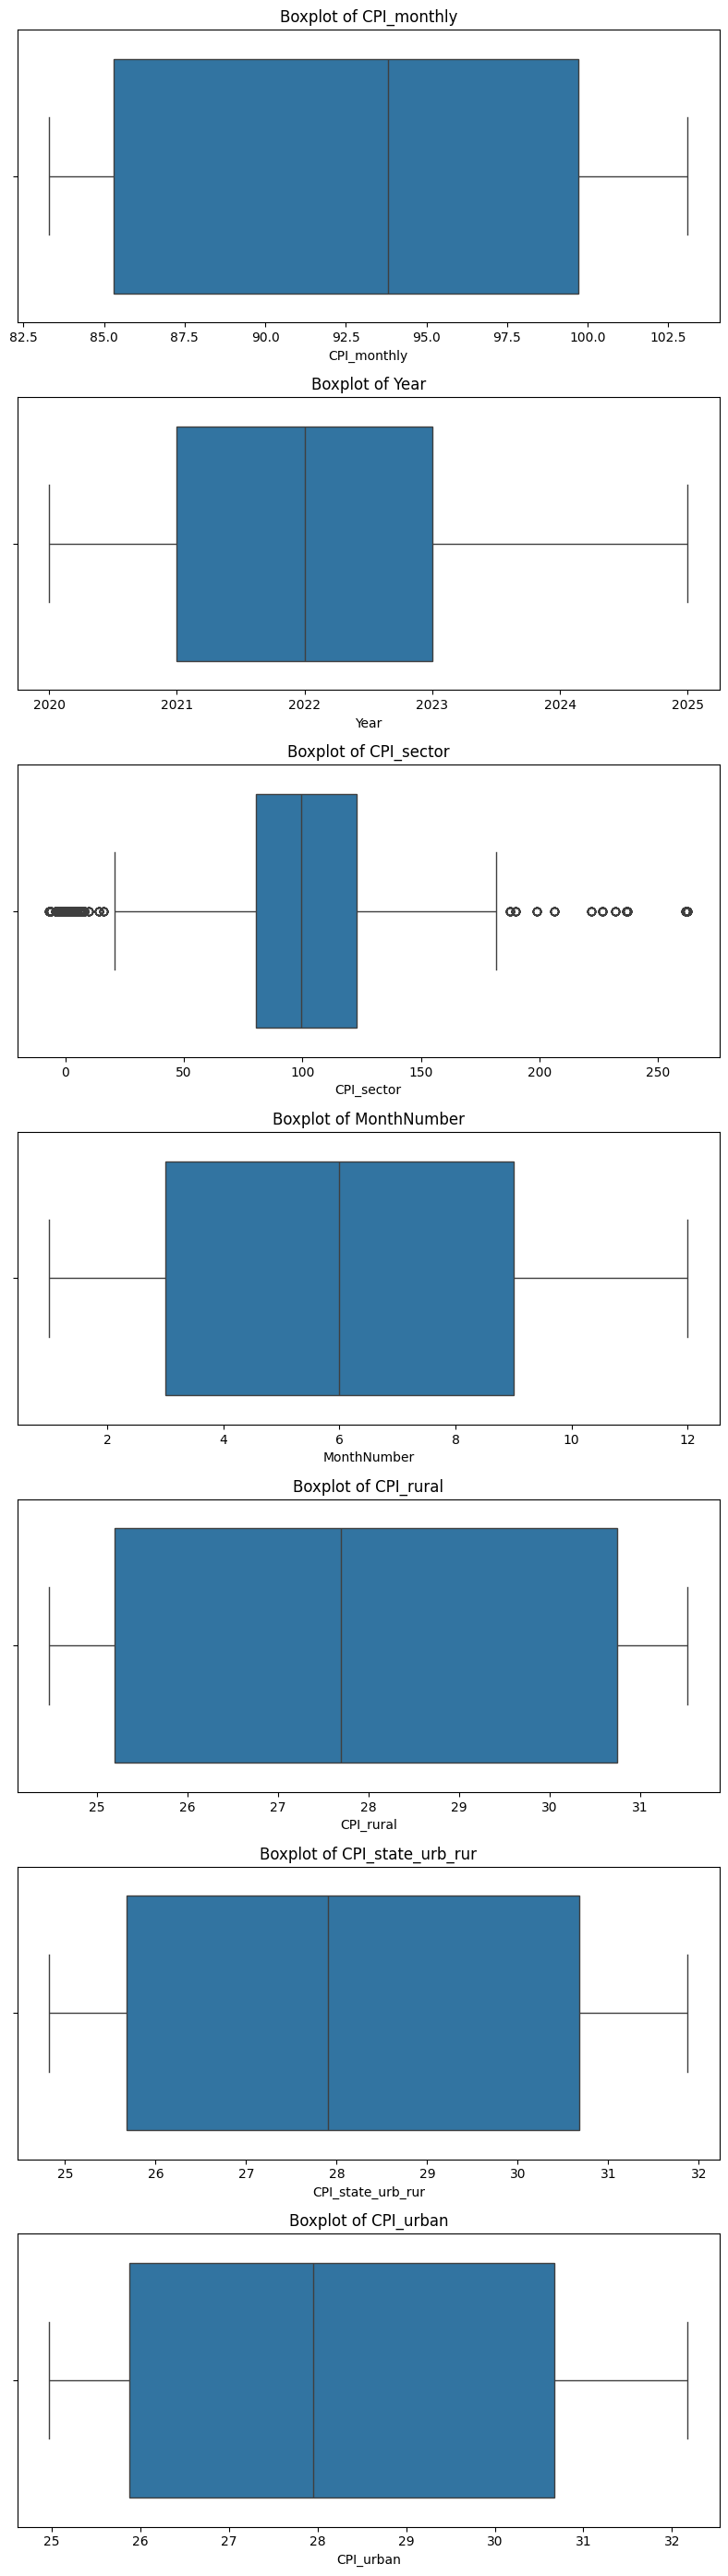

In [113]:
# OUTLIER

import numpy as np

numeric_cols = merged.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(8, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=merged[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()



In [114]:
recent = merged[merged["Month"] >= "2020-01-01"].dropna(subset=["CPI_urban","CPI_rural"])

In [115]:
# STANDARDIZATION
from sklearn.preprocessing import StandardScaler

scale_cols = ['CPI_monthly', 'CPI_sector', 'CPI_urban', 'CPI_rural']
available_scale_cols = [c for c in scale_cols if c in merged.columns]

scaler = StandardScaler()
merged_scaled = merged.copy()
merged_scaled[available_scale_cols] = scaler.fit_transform(merged_scaled[available_scale_cols])

print("\nScaled columns:", available_scale_cols)


Scaled columns: ['CPI_monthly', 'CPI_sector', 'CPI_urban', 'CPI_rural']


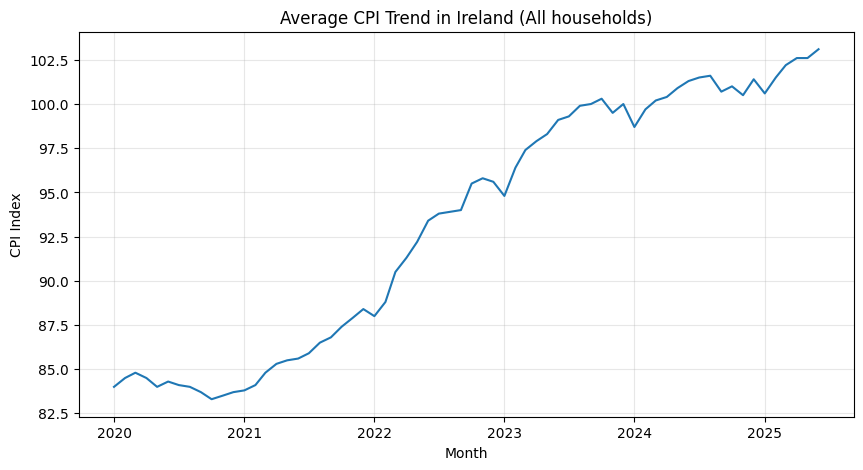

In [116]:
#PLOT OVERALL CPI INDEX TREND
overall_cpi = merged.groupby("Month")["CPI_monthly"].mean()
plt.figure(figsize=(10,5))
plt.plot(overall_cpi.index, overall_cpi.values)
plt.title("Average CPI Trend in Ireland (All households)")
plt.xlabel("Month")
plt.ylabel("CPI Index")
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1400x1000 with 0 Axes>

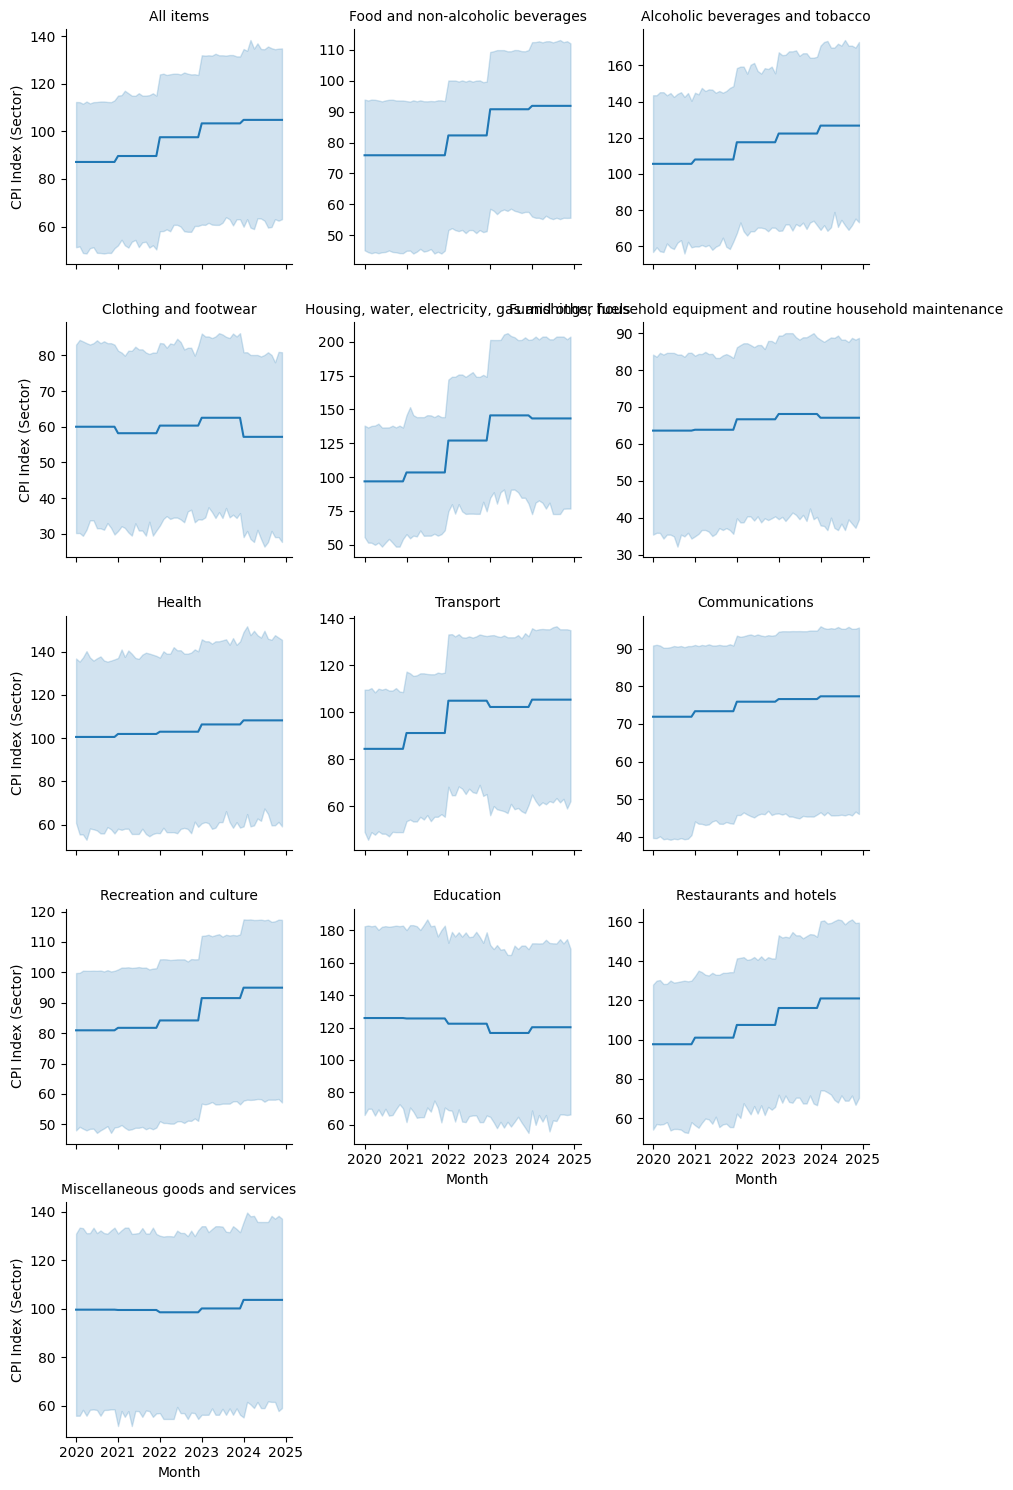

In [117]:
#PLOT CPI TRENDS BY CATEGORY/SECTOR
plt.figure(figsize=(14,10))
g = sns.relplot(data=merged,x="Month",y="CPI_sector",col="Category",col_wrap=3,kind="line",height=3,facet_kws={"sharey": False})

g.set_titles("{col_name}")
g.set_xlabels("Month")
g.set_ylabels("CPI Index (Sector)")
plt.tight_layout()
plt.show()


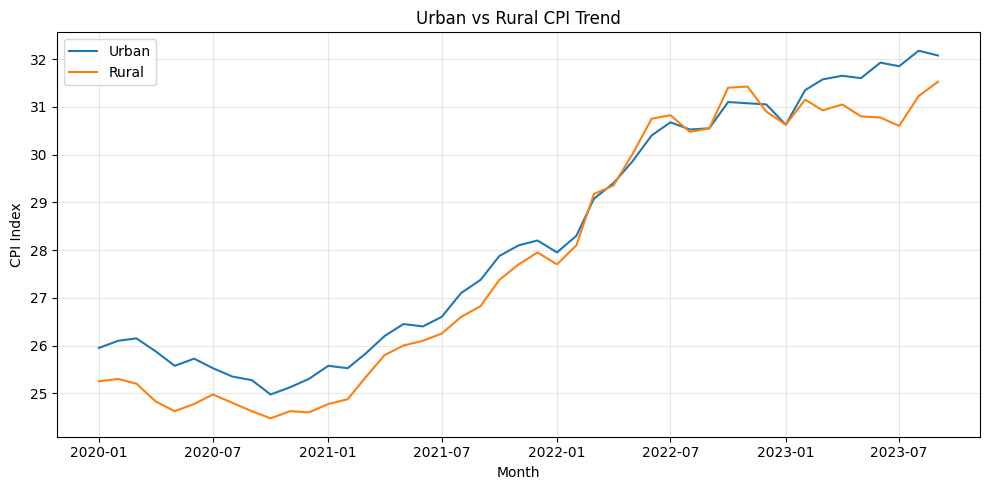

In [118]:
#COMPARE URBAN VS RURAL CPI
plt.figure(figsize=(10,5))
plt.plot(merged["Month"], merged["CPI_urban"], label="Urban")
plt.plot(merged["Month"], merged["CPI_rural"], label="Rural")
plt.title("Urban vs Rural CPI Trend")
plt.xlabel("Month")
plt.ylabel("CPI Index")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [119]:
# % change in urban vs rural CPI since 2018 and since 2020
merged = merged.sort_values("Month")
recent = merged[merged["Month"] >= "2018-01-01"]

In [120]:
# compute % change for urban and rural
def pct_change(series):
    first = series.iloc[0]
    last = series.iloc[-1]
    return (last - first) / first * 100

In [121]:
urban_pct = pct_change(recent["CPI_urban"])
rural_pct = pct_change(recent["CPI_rural"])

In [122]:
print(f"Urban CPI % change since 2018: {urban_pct:.1f}%")
print(f"Rural CPI % change since 2018: {rural_pct:.1f}%")

Urban CPI % change since 2018: nan%
Rural CPI % change since 2018: nan%


In [123]:
#recompute for 2020 onwards
recent = merged[merged["Month"] >= "2020-01-01"] \
             .dropna(subset=["CPI_urban", "CPI_rural"])

def pct_change(series):
    first = series.iloc[0]
    last = series.iloc[-1]
    return (last - first) / first * 100

urban_pct = pct_change(recent["CPI_urban"])
rural_pct = pct_change(recent["CPI_rural"])

print(f"Urban CPI % change since 2020: {urban_pct:.1f}%")
print(f"Rural CPI % change since 2020: {rural_pct:.1f}%")


Urban CPI % change since 2020: 23.6%
Rural CPI % change since 2020: 24.9%


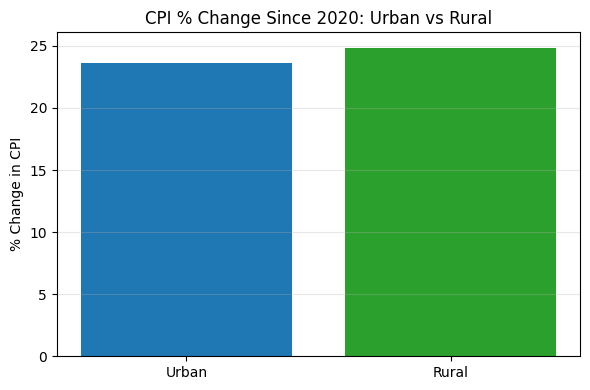

In [124]:
#bar chart comparing total % change for urban vs rural
labels = ['Urban', 'Rural']
values = [urban_pct, rural_pct]

plt.figure(figsize=(6,4))
plt.bar(labels, values, color=['tab:blue', 'tab:green'])
plt.title('CPI % Change Since 2020: Urban vs Rural')
plt.ylabel('% Change in CPI')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


From 2020 to 2024, prices for urban households increased by about 23.6%, while rural households saw an increase of 24.9%.

Calculate sector % change since 2020

In [125]:

merged["Month"] = pd.to_datetime(merged["Month"], errors="coerce")
merged = merged.sort_values("Month")


recent_sectors = merged[merged["Month"] >= "2020-01-01"]

#for each sector, take first and last CPI value
sector_change = (recent_sectors.groupby("Category")["CPI_sector"].agg(["first", "last"]).reset_index())

sector_change["Change_abs"] = sector_change["last"] - sector_change["first"]
sector_change["Change_pct"] = (
    (sector_change["last"] - sector_change["first"]) / sector_change["first"] * 100
)

sector_change = sector_change.sort_values("Change_pct", ascending=False)
print(sector_change.head(10))


                            Category  first   last  Change_abs  Change_pct
4                          Education  105.2  226.5       121.3  115.304183
5   Food and non-alcoholic beverages   95.5  110.3        14.8   15.497382
11            Restaurants and hotels   83.7    4.7       -79.0  -94.384707
10            Recreation and culture   86.8    4.4       -82.4  -94.930876
0    Alcoholic beverages and tobacco   85.9    3.7       -82.2  -95.692666
12                         Transport   81.4    2.6       -78.8  -96.805897
9   Miscellaneous goods and services  113.7    3.3      -110.4  -97.097625
1                          All items   84.0    2.1       -81.9  -97.500000
7                             Health   93.4    1.9       -91.5  -97.965739
3                     Communications   88.1    1.0       -87.1  -98.864926


Bar chart to show which sectors increased most

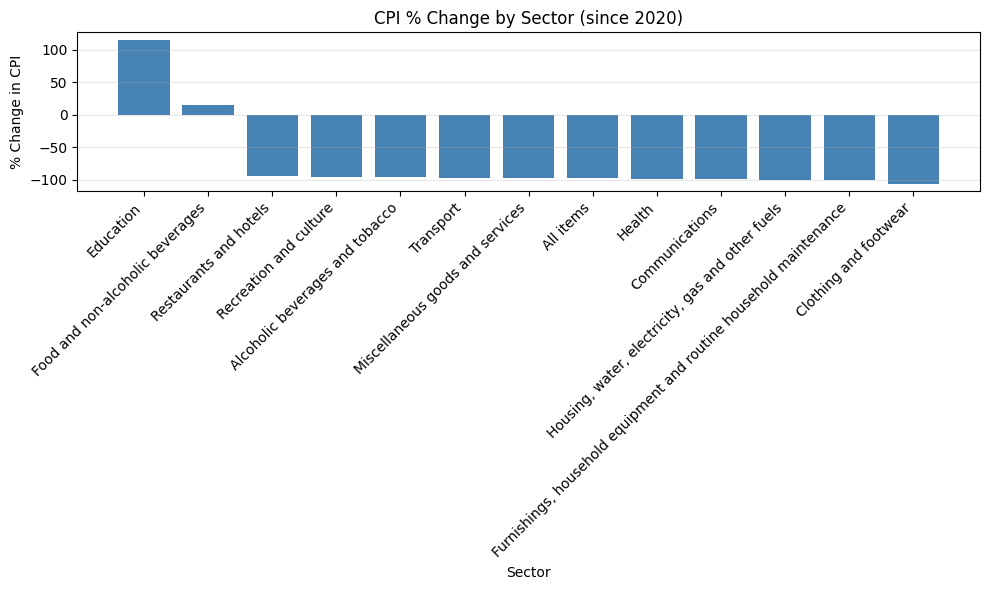

In [126]:
sector_change_sorted = sector_change.sort_values("Change_pct", ascending=False)

plt.figure(figsize=(10,6))
plt.bar(sector_change_sorted["Category"], sector_change_sorted["Change_pct"], color="steelblue")
plt.title("CPI % Change by Sector (since 2020)")
plt.xlabel("Sector")
plt.ylabel("% Change in CPI")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


ARIMA

In [127]:
from statsmodels.tsa.arima.model import ARIMA
#build monthly CPI series
cpi_ts = (merged.sort_values("Month").set_index("Month")["CPI_monthly"].resample("MS").mean())

cpi_ts = cpi_ts.dropna()
print(cpi_ts.head(), cpi_ts.tail())
print("Number of observations:", len(cpi_ts))

Month
2020-01-01    84.0
2020-02-01    84.5
2020-03-01    84.8
2020-04-01    84.5
2020-05-01    84.0
Freq: MS, Name: CPI_monthly, dtype: float64 Month
2025-02-01    101.5
2025-03-01    102.2
2025-04-01    102.6
2025-05-01    102.6
2025-06-01    103.1
Freq: MS, Name: CPI_monthly, dtype: float64
Number of observations: 66


<Figure size 1000x400 with 0 Axes>

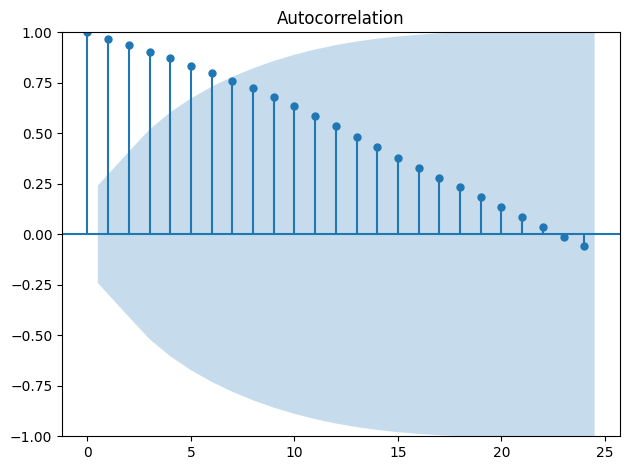

<Figure size 1000x400 with 0 Axes>

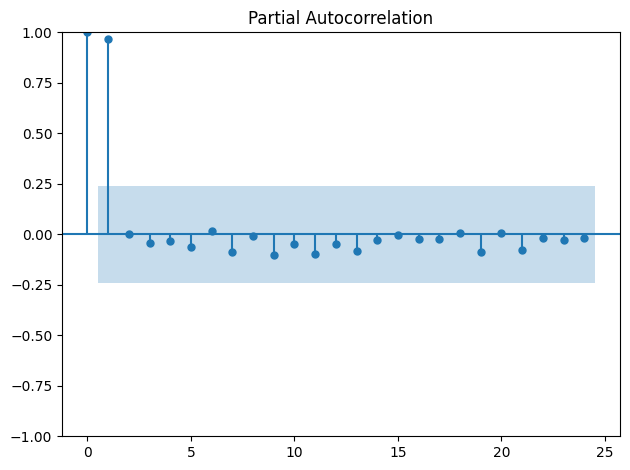

In [128]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#ACF and PACF plots to inspect autocorrelation
plt.figure(figsize=(10,4))
plot_acf(cpi_ts, lags=24)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(cpi_ts, lags=24, method="ywm")
plt.tight_layout()
plt.show()


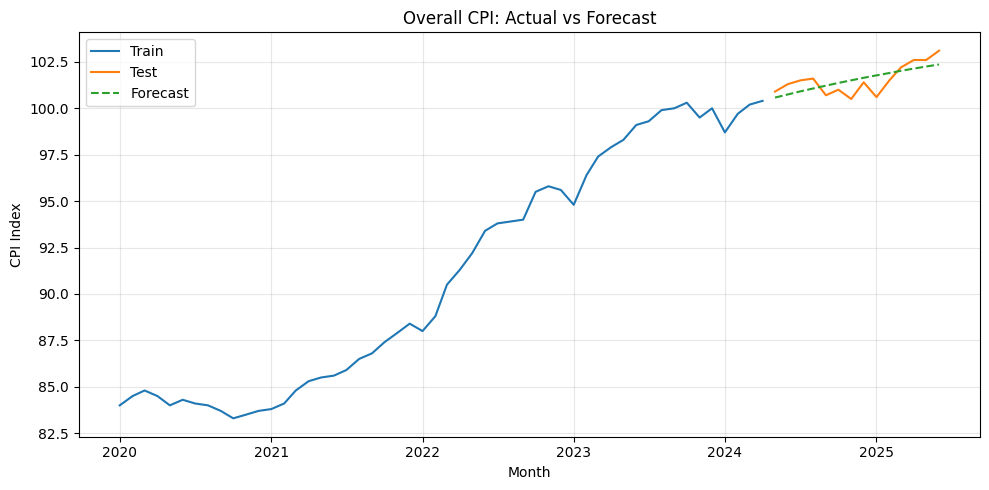

In [129]:
#train/test split (80/20) and ARIMA(1,1,1) fit
if len(cpi_ts) > 36:
    train_size = int(len(cpi_ts) * 0.8)
    train, test = cpi_ts.iloc[:train_size], cpi_ts.iloc[train_size:]


    model = ARIMA(train, order=(1,1,1))
    fit = model.fit()

    forecast = fit.forecast(steps=len(test))
#plot training data, test data and ARIMA forecast
    plt.figure(figsize=(10,5))
    plt.plot(train.index, train, label="Train")
    plt.plot(test.index, test, label="Test")
    plt.plot(test.index, forecast, label="Forecast", linestyle="--")
    plt.title("Overall CPI: Actual vs Forecast")
    plt.xlabel("Month"); plt.ylabel("CPI Index")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.show()
else:
    print("Not enough monthly observations for ARIMA.")

Blue = past CPI (training data), steadily rising.

Orange = recent actual CPI (test period).

Green dashed = model’s forecast, which continues the upward trend.

In [130]:
from statsmodels.tsa.arima.model import ARIMA
#ARIMA model selection using AIC/BIC
orders = [(1,1,0), (1,1,1), (2,1,1), (2,1,2)]
aic_results = []

for order in orders:
    model = ARIMA(train, order=order)
    fit = model.fit()
    aic_results.append({"order": order, "AIC": fit.aic, "BIC": fit.bic})

aic_results_df = pd.DataFrame(aic_results).sort_values("AIC")
aic_results_df


,order,AIC,BIC
1,"(1, 1, 1)",95.405380,101.200857
3,"(2, 1, 2)",96.533937,106.193065
2,"(2, 1, 1)",97.395204,105.122507
0,"(1, 1, 0)",101.114798,104.978449


In [131]:
#take best‑AIC order and refit ARIMA
best_order = tuple(aic_results_df.iloc[0]["order"])
model = ARIMA(train, order=best_order)
fit = model.fit()
forecast = fit.forecast(steps=len(test))


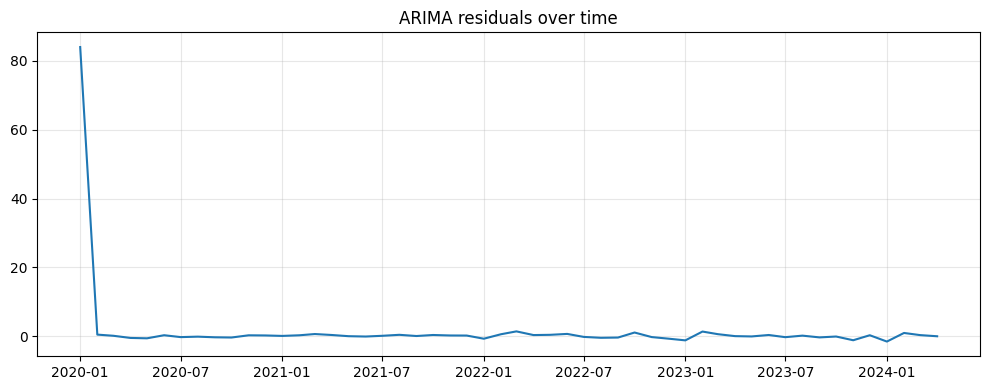

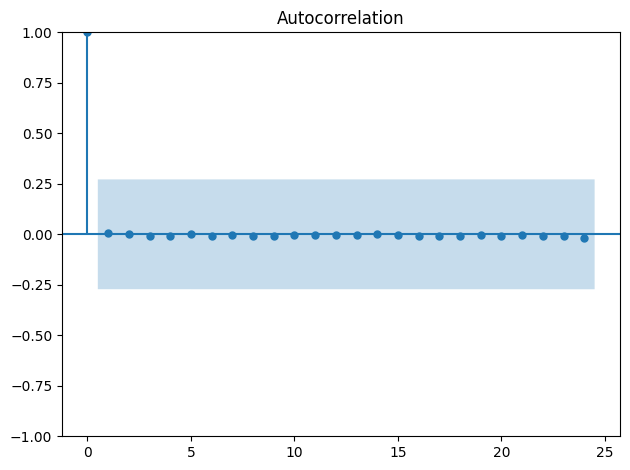

In [132]:
resid = fit.resid#check residuals

plt.figure(figsize=(10,4))
plt.plot(resid)
plt.title("ARIMA residuals over time")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plot_acf(resid.dropna(), lags=24)
plt.tight_layout()
plt.show()


Calculate simple error metrics

In [133]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
#error metrics for final ARIMA model

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE: 0.531
RMSE: 0.596


In [134]:
results = {}
#store ARIMA results in a common dictionary
results["ARIMA"] = {"MAE": mae, "RMSE": rmse}

Build supervised dataset

In [135]:
#build a supervised dataset: target is CPI_t, features are past 6 months
cpi_ts = (merged.sort_values("Month").set_index("Month")["CPI_monthly"].resample("MS").mean().dropna())


df_ml = pd.DataFrame({"CPI_t": cpi_ts})
for lag in range(1, 7):
    df_ml[f"CPI_t_minus_{lag}"] = cpi_ts.shift(lag)

df_ml = df_ml.dropna()

# train/test split(80/20) in time order
n = len(df_ml)
train_size = int(n * 0.8)
train_ml = df_ml.iloc[:train_size]
test_ml  = df_ml.iloc[train_size:]

X_train = train_ml.drop(columns=["CPI_t"])
y_train = train_ml["CPI_t"]
X_test  = test_ml.drop(columns=["CPI_t"])
y_test  = test_ml["CPI_t"]


In [136]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor


In [137]:
from sklearn.model_selection import TimeSeriesSplit
#time‑series cross‑validation helper to compare models by CV‑MAE
tscv = TimeSeriesSplit(n_splits=5)

def cv_mae(model):
    maes = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        maes.append(mean_absolute_error(y_val, preds))
    return np.mean(maes)

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=200, random_state=42)
mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=2000, random_state=42)

print("LR CV MAE:",  cv_mae(lr))
print("RF CV MAE:",  cv_mae(rf))
print("MLP CV MAE:", cv_mae(mlp))


LR CV MAE: 0.7623833379520271
RF CV MAE: 2.312962500000058
MLP CV MAE: 3.534476644842261


Linear Regression (baseline ML),
Random Forest,
MLPRegressor (simple neural net).

In [138]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
results["LinearRegression"] = {"MAE": mae_lr, "RMSE": rmse_lr}

In [139]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
results["RandomForest"] = {"MAE": mae_rf, "RMSE": rmse_rf}


In [140]:
mlp = MLPRegressor(hidden_layer_sizes=(50,), activation="relu",max_iter=2000, random_state=42)
mlp.fit(X_train, y_train)
pred_mlp = mlp.predict(X_test)
mae_mlp = mean_absolute_error(y_test, pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, pred_mlp))
results["MLP"] = {"MAE": mae_mlp, "RMSE": rmse_mlp}

In [141]:

results = {
    "LinearRegression": {"MAE": mae_lr,  "RMSE": rmse_lr},
    "RandomForest":    {"MAE": mae_rf,  "RMSE": rmse_rf},
    "MLP":             {"MAE": mae_mlp, "RMSE": rmse_mlp},
    "ARIMA":           {"MAE": mae,     "RMSE": rmse},
}
#collect all model metrics into a table and sort by RMSE
results_df = pd.DataFrame(results).T
results_df = results_df[["MAE", "RMSE"]]

results_df_sorted = results_df.sort_values("RMSE")
print(results_df_sorted)

#identify best model
best_model = results_df_sorted.index[0]
best_mae = results_df_sorted.iloc[0]["MAE"]
best_rmse = results_df_sorted.iloc[0]["RMSE"]
print(f"\nBest model overall: {best_model} (MAE={best_mae:.3f}, RMSE={best_rmse:.3f})")


                       MAE      RMSE
LinearRegression  0.441033  0.575136
ARIMA             0.531327  0.595771
RandomForest      1.070625  1.326171
MLP               5.904195  5.944876

Best model overall: LinearRegression (MAE=0.441, RMSE=0.575)


In [72]:
#Next‑month CPI forecast using ARIMA and LSTM
cpi_ts = (merged.sort_values("Month").set_index("Month")["CPI_monthly"].resample("MS").mean().dropna())

# ARIMA next  month forecast
from statsmodels.tsa.arima.model import ARIMA

best_order = (1, 1, 1)
arima_full = ARIMA(cpi_ts, order=best_order).fit()
next_arima = float(arima_full.forecast(steps=1).iloc[0])

#  LSTMforecast

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

window = 12  #use last 12 months as input window

def make_lstm_dataset(series, window):
    vals = series.values.astype("float32")
    X, y = [], []
    for i in range(len(vals) - window):
        X.append(vals[i:i+window])
        y.append(vals[i+window])
    X = np.array(X)
    y = np.array(y)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    return X, y

X_all, y_all = make_lstm_dataset(cpi_ts, window)

model_lstm = Sequential([LSTM(50, input_shape=(window, 1)),Dense(1)])
model_lstm.compile(optimizer="adam", loss="mse")
model_lstm.fit(X_all, y_all, epochs=50, batch_size=16, verbose=0)

#build last 12‑month window and predict next month
last_window = cpi_ts.values[-window:].astype("float32")
last_window = last_window.reshape((1, window, 1))
next_lstm = float(model_lstm.predict(last_window, verbose=0)[0, 0])

print("Next‑month CPI forecast (ARIMA, benchmark):", round(next_arima, 2))
print("Next‑month CPI forecast (LSTM, MAIN):      ", round(next_lstm, 2))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Next‑month CPI forecast (ARIMA, benchmark): 103.29
Next‑month CPI forecast (LSTM, MAIN):       16.7
